# Light sensor
## Preparation of measurement data
- Measure light data with the phyphox app
- Save the screenshot of the graph from the app
- Export the data in a suitable way and load it into the VM
- Important: The number format must not be shortened

## Preparation Influx
- Create a token
- Create a bucket and ensure that the data is not deleted
- For a new attempt, it may be useful to delete the bucket and redefine it

## Preparing Jupyter for Influx
- Call up the interpreter configuration.
- Search for the configuration for Influx.
- Enter and save the URL, organization and token.

In [49]:
!pip install influxdb_client

Defaulting to user installation because normal site-packages is not writeable


In [50]:
import influxdb_client
from influxdb_client.client.write_api import SYNCHRONOUS
import time

In [51]:
# Be sure to adjust this information
path = '/home/bfh/rtdp/bfh-rtdp/roller/'
bucket = "bfh"
org = "bfh"
token = "7GI7A2cyVrR7_GsmFI-CQzPFWHbguzIJmHj_XvfrmttOVnEqCKn6NefOYnBdybQVqEmZAu8gfdYbyqjgblmB6w=="
url="http://localhost:8086"

separator = ";"

In [52]:
client = influxdb_client.InfluxDBClient(
   url=url,
   token=token,
   org=org
)

In [53]:
with open (path+'RawData.csv') as f:
    lines = [line for line in f]

In [54]:
data = []

data.append(lines[0].strip())

for line in lines[1:]:
    points = line.strip().split(separator)
    converted_points = [float(point.replace(",", ".")) for point in points]
    data.append( separator.join(map(str, converted_points)))

print(data)

# print(lines[0])
# print(lines[1])
# print(len(lines))
# line = lines[1]
# print(line)
# line.split(separator)
# tdata = float(line.split(separator)[0])
# lxdata = float(line.split(separator)[1])
# print(tdata)
# print(lxdata)

['"Time (s)";"Gyroscope x (rad/s)";"Gyroscope y (rad/s)";"Gyroscope z (rad/s)";"Absolute (rad/s)"', '0.02120541666;0.00455408683;-0.01811040565;0.007251800038;0.02003285061', '0.03127241667;0.03595435247;-0.02179968171;0.01254882757;0.04387954714', '0.04133941667;0.05853827298;-0.04738147557;0.004797847476;0.07546358705', '0.05140641666;0.06698528677;-0.08711930364;0.01329492964;0.1106957852', '0.06147341667;0.07157151401;-0.115077734;0.01736680418;0.136627129', '0.07153941666;0.06314153969;-0.09425713867;0.01909546182;0.1150473767', '0.08160641667;0.04976155609;-0.06053323299;0.02433532849;0.08205298881', '0.09167341667;0.03701566905;-0.04204796255;0.03018602915;0.06363479603', '0.1017404167;0.02341601066;-0.04057234153;0.03020445444;0.05573807963', '0.1118074167;0.01317296177;-0.02892234176;0.02227622457;0.03881055212', '0.1218744167;0.002119549783;-0.0004976592027;0.01826236024;0.01839168175', '0.1319404167;0.00703973975;0.01229563449;0.01817261241;0.02304309886', '0.1420074167;0.01

In [55]:
# Start Timestamp initialisieren gemäss Metadaten der Messung (File meta/time.csv)

ts = 1774103553.500

In [56]:
write_api = client.write_api(write_options=SYNCHRONOUS)

In [57]:
count=0
TIME_INDEX = 0
GYRO_X_INDEX = 1
GYRO_Y_INDEX = 2
GYRO_Z_INDEX = 3
ABS_INDEX = 4

map = [
    {
        "name": "gyro_x",
        "field": "lx",
        "index": GYRO_X_INDEX
    },
    {
        "name": "gyro_y",
        "field": "ly",
        "index": GYRO_Y_INDEX
    },
    {
        "name": "gyro_z",
        "field": "lz",
        "index": GYRO_Z_INDEX
    },
    {
        "name": "gyro_abs",
        "field": "abs",
        "index": ABS_INDEX
    }
]

for mapping in map:
    for line in data[1:]:
        parts = line.strip().split(separator)
        tdata = float(parts[TIME_INDEX])
        lxdata = float(parts[mapping["index"]])


        punkt = influxdb_client.Point(mapping["name"]) \
            .field(mapping["field"], lxdata)  \
            .time(int((ts+tdata)*1000), write_precision='ms')
        print(punkt)

        if (int(tdata) > 0):
            write_api.write(bucket=bucket, record=punkt)

        count += 1
print(count)

gyro_x lx=0.00455408683 1774103553521
gyro_x lx=0.03595435247 1774103553531
gyro_x lx=0.05853827298 1774103553541
gyro_x lx=0.06698528677 1774103553551
gyro_x lx=0.07157151401 1774103553561
gyro_x lx=0.06314153969 1774103553571
gyro_x lx=0.04976155609 1774103553581
gyro_x lx=0.03701566905 1774103553591
gyro_x lx=0.02341601066 1774103553601
gyro_x lx=0.01317296177 1774103553611
gyro_x lx=0.002119549783 1774103553621
gyro_x lx=0.00703973975 1774103553631
gyro_x lx=0.01659702696 1774103553642
gyro_x lx=0.02971016616 1774103553652
gyro_x lx=0.04920027405 1774103553662
gyro_x lx=0.04990574345 1774103553672
gyro_x lx=0.03025463037 1774103553682
gyro_x lx=-0.001629264909 1774103553692
gyro_x lx=-0.01885349303 1774103553702
gyro_x lx=-0.03687244281 1774103553712
gyro_x lx=-0.04602155089 1774103553722
gyro_x lx=-0.05263684317 1774103553732
gyro_x lx=-0.04688063264 1774103553742
gyro_x lx=-0.03620029241 1774103553752
gyro_x lx=-0.02838772722 1774103553762
gyro_x lx=-0.03209937736 1774103553772
g

gyro_x lx=-0.9879214764 1774103554880
gyro_x lx=-0.8697572351 1774103554890
gyro_x lx=-0.6835373044 1774103554900
gyro_x lx=-0.4794985056 1774103554910
gyro_x lx=-0.2900849283 1774103554920
gyro_x lx=-0.1143434346 1774103554930
gyro_x lx=-0.03788701072 1774103554940
gyro_x lx=-0.05600107461 1774103554950
gyro_x lx=-0.1449860781 1774103554960
gyro_x lx=-0.2956227958 1774103554970
gyro_x lx=-0.488807708 1774103554980
gyro_x lx=-0.6750755906 1774103554990
gyro_x lx=-0.8207606673 1774103555001
gyro_x lx=-0.880099833 1774103555011
gyro_x lx=-0.8441317081 1774103555021
gyro_x lx=-0.73537606 1774103555031
gyro_x lx=-0.5755139589 1774103555041
gyro_x lx=-0.3756167889 1774103555051
gyro_x lx=-0.1779359132 1774103555061
gyro_x lx=-0.02276048809 1774103555071
gyro_x lx=0.09069629759 1774103555081
gyro_x lx=0.1506138444 1774103555091
gyro_x lx=0.174898684 1774103555101
gyro_x lx=0.1975316107 1774103555111
gyro_x lx=0.2257392704 1774103555121
gyro_x lx=0.2637735903 1774103555131
gyro_x lx=0.2857891

In [58]:
query_api = client.query_api()

In [69]:
start_time = int(ts + float(data[1].split(separator)[TIME_INDEX]))
end_time = int(ts + float(data[-1].split(separator)[TIME_INDEX]))

from datetime import datetime, timezone

def to_rfc3339(secs):
    return datetime.fromtimestamp(secs, tz=timezone.utc).isoformat()

start_rfc3339 = to_rfc3339(start_time)
end_rfc3339 = to_rfc3339(end_time)

print("Start time:", start_rfc3339)
print("End time:", end_rfc3339)

Start time: 2026-03-21T14:32:33+00:00
End time: 2026-03-21T14:32:56+00:00


In [79]:
query = f'''from(bucket: "bfh")
|> range(start: {start_rfc3339}, stop: {end_rfc3339})
|> filter(fn: (r) => r._measurement == "gyro_x")
|> filter(fn: (r) => r._field == "lx")'''

from(bucket: "bfh")
|> range(start: 2026-03-21T14:32:33+00:00, stop: 2026-03-21T14:32:56+00:00)
|> filter(fn: (r) => r._measurement == "gyro_x")
|> filter(fn: (r) => r._field == "lx")


In [71]:
result = query_api.query(org=org, query=query)

In [72]:
results = []
for table in result:
  for record in table.records:
    results.append((record.get_time(), record.get_value()))

print(results)

[(datetime.datetime(2026, 3, 21, 14, 32, 34, 507000, tzinfo=tzutc()), -0.1072810814), (datetime.datetime(2026, 3, 21, 14, 32, 34, 517000, tzinfo=tzutc()), -0.1020538285), (datetime.datetime(2026, 3, 21, 14, 32, 34, 527000, tzinfo=tzutc()), -0.09380878508), (datetime.datetime(2026, 3, 21, 14, 32, 34, 537000, tzinfo=tzutc()), -0.08671039343), (datetime.datetime(2026, 3, 21, 14, 32, 34, 548000, tzinfo=tzutc()), -0.08692357689), (datetime.datetime(2026, 3, 21, 14, 32, 34, 558000, tzinfo=tzutc()), -0.1111708581), (datetime.datetime(2026, 3, 21, 14, 32, 34, 568000, tzinfo=tzutc()), -0.1730167866), (datetime.datetime(2026, 3, 21, 14, 32, 34, 578000, tzinfo=tzutc()), -0.2667134404), (datetime.datetime(2026, 3, 21, 14, 32, 34, 588000, tzinfo=tzutc()), -0.3406259716), (datetime.datetime(2026, 3, 21, 14, 32, 34, 598000, tzinfo=tzutc()), -0.3641012013), (datetime.datetime(2026, 3, 21, 14, 32, 34, 608000, tzinfo=tzutc()), -0.3329493105), (datetime.datetime(2026, 3, 21, 14, 32, 34, 618000, tzinfo=tz

In [73]:
results

[(datetime.datetime(2026, 3, 21, 14, 32, 34, 507000, tzinfo=tzutc()),
  -0.1072810814),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 517000, tzinfo=tzutc()),
  -0.1020538285),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 527000, tzinfo=tzutc()),
  -0.09380878508),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 537000, tzinfo=tzutc()),
  -0.08671039343),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 548000, tzinfo=tzutc()),
  -0.08692357689),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 558000, tzinfo=tzutc()),
  -0.1111708581),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 568000, tzinfo=tzutc()),
  -0.1730167866),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 578000, tzinfo=tzutc()),
  -0.2667134404),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 588000, tzinfo=tzutc()),
  -0.3406259716),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 598000, tzinfo=tzutc()),
  -0.3641012013),
 (datetime.datetime(2026, 3, 21, 14, 32, 34, 608000, tzinfo=tzutc()),
  -0.3329493105),
 (datetime.datetime(2026, 3, 

In [74]:
type(results)

list

In [75]:
import pandas as pd

In [76]:
res_df = pd.DataFrame(results, columns=['time', 'value', ])
res_df.set_index('time')

,value
time,
2026-03-21 14:32:34.507000+00:00,-0.107281
2026-03-21 14:32:34.517000+00:00,-0.102054
2026-03-21 14:32:34.527000+00:00,-0.093809
2026-03-21 14:32:34.537000+00:00,-0.086710
2026-03-21 14:32:34.548000+00:00,-0.086924
...,...
2026-03-21 14:32:55.950000+00:00,0.359807
2026-03-21 14:32:55.960000+00:00,0.630048
2026-03-21 14:32:55.970000+00:00,0.949971


<Axes: xlabel='time'>

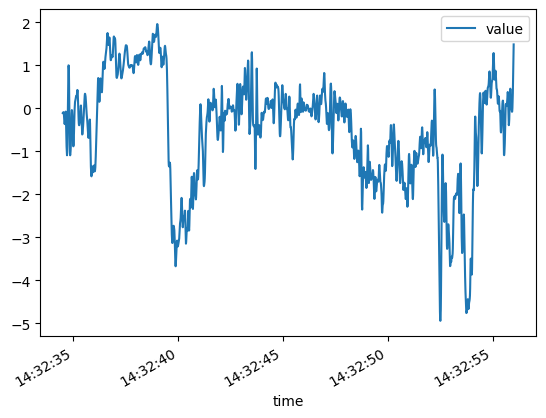

In [77]:
res_df.plot.line(x='time')
# More examples here : https://www.statology.org/pandas-plot-index/

In [78]:
from datetime import datetime

# Get the current datetime object
now = datetime.now()

# Convert the datetime object to a Unix timestamp (seconds since epoch)
unix_timestamp = now.timestamp()

# Print the Unix timestamp
print(unix_timestamp)

1774104972.922499
